In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# optional: make plots look cleaner
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Original shape:", df.shape)
display(df.head())
print(df.info())

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Missing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling   

In [5]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Drop customerID
df = df.drop("customerID", axis=1)

print("Shape after cleaning:", df.shape)
print(df.dtypes)

Shape after cleaning: (7043, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [6]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


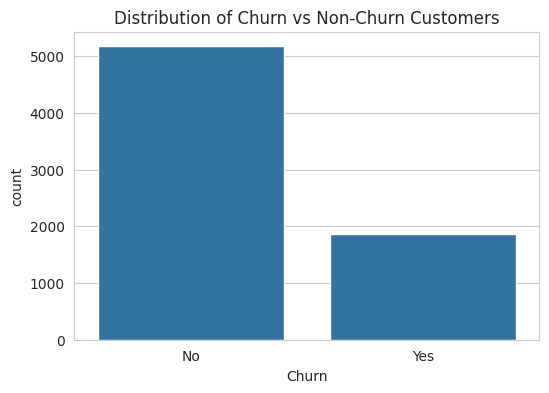

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Churn vs Non-Churn Customers")
plt.show()

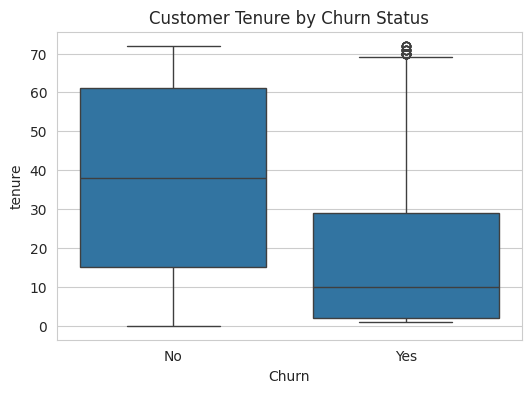

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Customer Tenure by Churn Status")
plt.show()

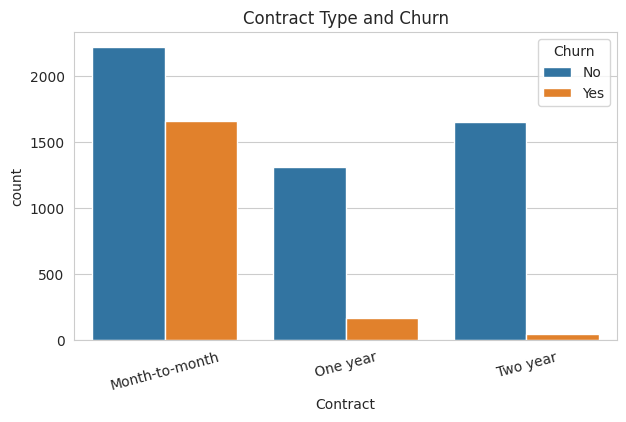

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type and Churn")
plt.xticks(rotation=15)
plt.show()

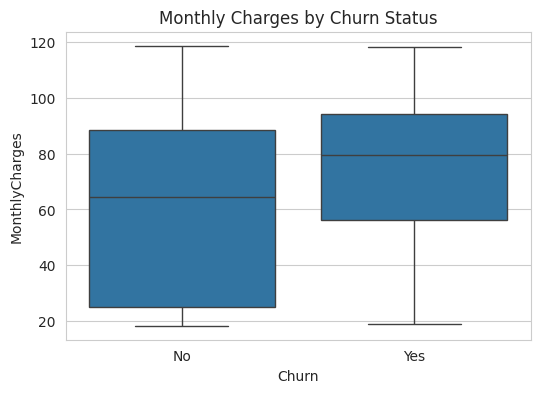

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

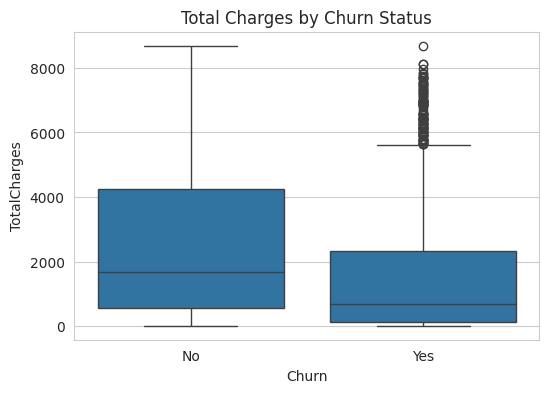

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.show()

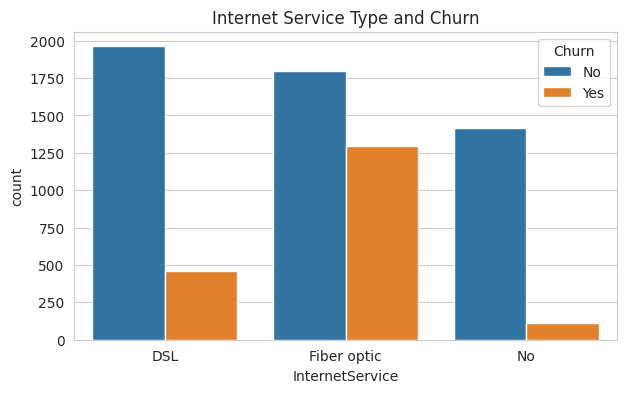

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service Type and Churn")
plt.show()

In [13]:
# Define y
y = df["Churn"].map({"Yes": 1, "No": 0})

# Define X
X = df.drop("Churn", axis=1)

# One-hot encode X only
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (7043, 30)
y shape: (7043,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [14]:
# First split: train 80%, temp 20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: validation 10%, test 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (5634, 30) (5634,)
Validation shape: (704, 30) (704,)
Test shape: (705, 30) (705,)


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [16]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1
    })

    print("\n" + "="*50)
    print(f"Model: {name}")
    print("="*50)
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.8
Precision: 0.6494
Recall: 0.5348
F1 Score: 0.5865
Confusion Matrix:
 [[464  54]
 [ 87 100]]

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       518
           1       0.65      0.53      0.59       187

    accuracy                           0.80       705
   macro avg       0.75      0.72      0.73       705
weighted avg       0.79      0.80      0.79       705


Model: Decision Tree
Accuracy: 0.7277
Precision: 0.4862
Recall: 0.4706
F1 Score: 0.4783
Confusion Matrix:
 [[425  93]
 [ 99  88]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       518
           1       0.49      0.47      0.48       187

    accuracy                           0.73       705
   macro avg       0.65      0.65      0.65       705
weighted avg       0.72      0.73      0.73       705


Model: Random Forest
Accuracy:

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800000,0.649351,0.534759,0.586510
2,Random Forest,0.784397,0.625899,0.465241,0.533742
1,Decision Tree,0.727660,0.486188,0.470588,0.478261


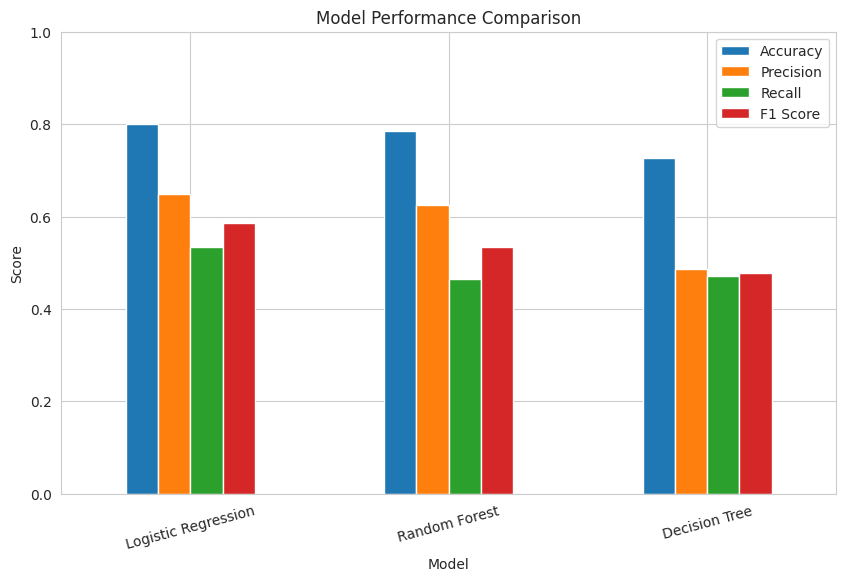

In [18]:
results_df_plot = results_df.set_index("Model")

results_df_plot.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

In [19]:
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Importance
3,TotalCharges,0.194123
1,tenure,0.171364
2,MonthlyCharges,0.167562
10,InternetService_Fiber optic,0.038864
28,PaymentMethod_Electronic check,0.038285
25,Contract_Two year,0.031477
4,gender_Male,0.028519
13,OnlineSecurity_Yes,0.027796
26,PaperlessBilling_Yes,0.025725
5,Partner_Yes,0.023285


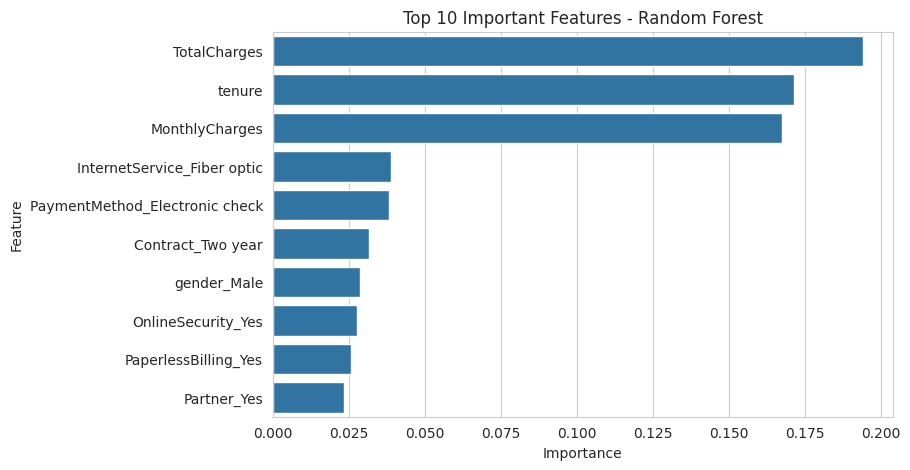

In [20]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top10, x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [21]:
best_model = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1 Score"]

print(f"Best model based on F1 Score: {best_model}")
print(f"Best F1 Score: {best_f1:.4f}")

Best model based on F1 Score: Logistic Regression
Best F1 Score: 0.5865
